## 长度分布可视化

ERROR:root:Unsupported data type: 
ERROR:root:Unsupported data type: 
ERROR:root:Unsupported data type: 
ERROR:root:Unsupported data type: 
ERROR:root:Unsupported data type: 
ERROR:root:Unsupported data type: 
ERROR:root:Unsupported data type: .16477022236
ERROR:root:Unsupported cell attribute type: -0.74197758445 for file: D:\github\Phd_summary\1_Data\2_Nagahama\1_Centerline\1_from chen\00000802.nii_R_ICA_labeled.vtk
ERROR:root:Unsupported data type: 
ERROR:root:Unsupported data type: 
ERROR:root:Unsupported data type: 
ERROR:root:Unsupported data type: -nan(ind)
ERROR:root:Unsupported cell attribute type: 6.9770608134e-18 for file: D:\github\Phd_summary\1_Data\2_Nagahama\1_Centerline\1_from chen\00001454.nii_R_ICA_labeled.vtk
ERROR:root:Unsupported data type: 
ERROR:root:Unsupported data type: .27630379481
ERROR:root:Unsupported cell attribute type: 0.86895944355 for file: D:\github\Phd_summary\1_Data\2_Nagahama\1_Centerline\1_from chen\00001612.nii_R_ICA_labeled.vtk
ERROR:root:Unsup

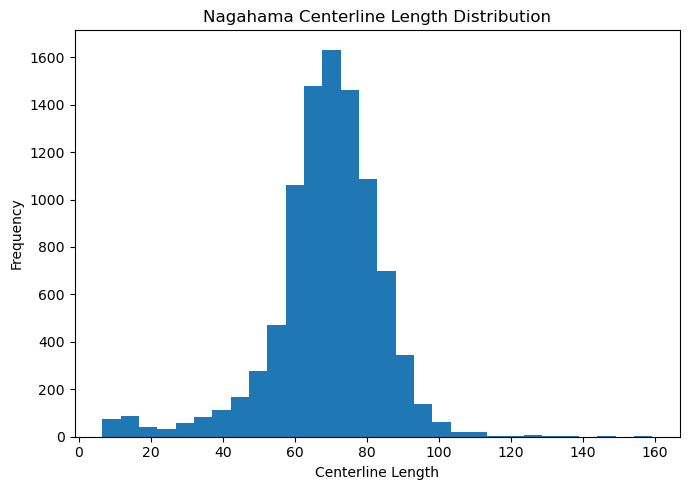

In [5]:
import os
import numpy as np
import pyvista as pv
import matplotlib.pyplot as plt

root_dir = r"D:\github\Phd_summary\1_Data\2_Nagahama\1_Centerline\1_from chen"

lengths = []

def compute_centerline_length(poly):
    """
    按 connectivity 顺序计算中心线弧长
    """
    lines = poly.lines
    if lines.size == 0:
        return np.nan

    n_pts = lines[0]
    ids = lines[1:n_pts + 1]
    pts = poly.points[ids]

    return np.linalg.norm(np.diff(pts, axis=0), axis=1).sum()

for fname in os.listdir(root_dir):
    if not fname.lower().endswith(".vtk"):
        continue

    poly = pv.read(os.path.join(root_dir, fname))
    length = compute_centerline_length(poly)

    if not np.isnan(length):
        lengths.append(length)

# ===== 画分布图 =====
plt.figure(figsize=(7, 5))
plt.hist(lengths, bins=30)
plt.xlabel("Centerline Length")
plt.ylabel("Frequency")
plt.title("Nagahama Centerline Length Distribution")
plt.tight_layout()
plt.show()


## 去除短的中心线（60以下）

In [16]:
import os
import numpy as np
import pyvista as pv
import logging
import shutil

# ===== 关闭 VTK / PyVista 的刷屏日志 =====
logging.getLogger().setLevel(logging.CRITICAL)

# ===== 路径 =====
src_dir = r"D:\github\Phd_summary\1_Data\2_Nagahama\1_Centerline\1_from chen"
dst_dir = r"D:\github\Phd_summary\1_Data\2_Nagahama\1_Centerline\2_centerline_60"

os.makedirs(dst_dir, exist_ok=True)

def compute_centerline_length(poly):
    """
    按 LINES connectivity 计算中心线真实弧长
    （只用于筛选，不改变任何数据）
    """
    lines = poly.lines
    if lines.size == 0:
        return np.nan

    n_pts = int(lines[0])
    ids = lines[1:n_pts + 1]
    pts = poly.points[ids]

    return np.linalg.norm(np.diff(pts, axis=0), axis=1).sum()

# ===== 统计量 =====
total = 0
kept = 0
removed = 0

for fname in os.listdir(src_dir):
    if not fname.lower().endswith(".vtk"):
        continue

    total += 1
    src_path = os.path.join(src_dir, fname)

    try:
        poly = pv.read(src_path)

        # 基本合法性检查
        if poly.GetClassName() != "vtkPolyData" or poly.lines.size == 0:
            removed += 1
            continue

        length = compute_centerline_length(poly)

        # 长度筛选（≥ 60）
        if np.isnan(length) or length < 60.0:
            removed += 1
            continue

        # ===== 关键点：原样复制，不重新写 =====
        shutil.copy2(src_path, os.path.join(dst_dir, fname))
        kept += 1

    except Exception:
        removed += 1
        continue

# ===== 打印结果 =====
print("===== Centerline count summary =====")
print(f"Total centerlines (before): {total}")
print(f"Kept (length ≥ 60):         {kept}")
print(f"Removed:                   {removed}")


===== Centerline count summary =====
Total centerlines (before): 9432
Kept (length ≥ 60):         7559
Removed:                   1873


## 改成txt（间隔0.3）

In [17]:
import os
import numpy as np
import pyvista as pv
import logging

# ===== 关闭刷屏日志 =====
logging.getLogger().setLevel(logging.CRITICAL)

# ===== 输入 / 输出目录 =====
src_dir = r"D:\github\Phd_summary\1_Data\2_Nagahama\1_Centerline\2_centerline_60"
dst_dir = r"D:\github\Phd_summary\1_Data\2_Nagahama\1_Centerline\3_centerline_60_txt"

os.makedirs(dst_dir, exist_ok=True)

SPACING = 0.3  # 目标点间距（单位与坐标一致）

def extract_ordered_points(poly):
    """按 LINES connectivity 提取有序中心线点"""
    lines = poly.lines
    n_pts = int(lines[0])
    ids = lines[1:n_pts + 1].astype(int)
    return poly.points[ids]

def resample_by_arclength(pts, ds):
    """
    沿真实弧长以固定间距 ds 重采样
    返回：重采样后的点 (N,3)
    """
    # 原始弧长
    s = np.zeros(len(pts))
    s[1:] = np.cumsum(np.linalg.norm(np.diff(pts, axis=0), axis=1))

    total_len = s[-1]
    if total_len <= ds:
        return pts.copy()

    s_new = np.arange(0.0, total_len + 1e-8, ds)

    x_new = np.interp(s_new, s, pts[:, 0])
    y_new = np.interp(s_new, s, pts[:, 1])
    z_new = np.interp(s_new, s, pts[:, 2])

    return np.column_stack([x_new, y_new, z_new])

def export_txt(points, txt_path):
    with open(txt_path, "w") as f:
        f.write(f"#spline3d {len(points)}\n")
        for x, y, z in points:
            f.write(f"{x:.8f} {y:.8f} {z:.8f}\n")

# ===== 主循环 =====
count = 0

for fname in os.listdir(src_dir):
    if not fname.lower().endswith(".vtk"):
        continue

    vtk_path = os.path.join(src_dir, fname)

    try:
        poly = pv.read(vtk_path)
        if poly.GetClassName() != "vtkPolyData" or poly.lines.size == 0:
            continue

        # 1. 提取中心线顺序点
        pts = extract_ordered_points(poly)

        # 2. 按 0.3 重采样
        pts_resampled = resample_by_arclength(pts, SPACING)

        # 3. 导出 txt
        txt_name = os.path.splitext(fname)[0] + ".txt"
        txt_path = os.path.join(dst_dir, txt_name)
        export_txt(pts_resampled, txt_path)

        count += 1

    except Exception:
        continue

print(f"Exported txt files: {count}")


Exported txt files: 7559


## 计算曲率

In [18]:
import os
import subprocess

# === 路径设置 ===
input_dir = r"D:\github\Phd_summary\1_Data\2_Nagahama\1_Centerline\3_centerline_60_txt"
exe_path = r"D:\github\Phd_summary\2_Code\1_Brava\1_Preprocessing\curvature\code\curvature\batchVModeler.exe"
param_file = r"D:\github\Phd_summary\2_Code\1_Brava\1_Preprocessing\curvature\code\curvature\param_5d_L3.txt"
output_root = r"D:\github\Phd_summary\1_Data\2_Nagahama\1_Centerline\4_centerline_60_curvature"

# === 固定参数 ===
mode_number = "1030"
flag1 = "1"
flag2 = "1"
flag3 = "1"
scale = "1.0"

# === 遍历每个 txt 文件 ===
for fn in os.listdir(input_dir):
    if not fn.endswith(".txt"):
        continue

    input_file = os.path.join(input_dir, fn)
    base_name = os.path.splitext(fn)[0]  # 去掉后缀
    out_dir = os.path.join(output_root, base_name)
    os.makedirs(out_dir, exist_ok=True)

    # 拼接命令
    cmd = [
        exe_path,
        mode_number,
        input_file,
        param_file,
        flag1, flag2, flag3,
        out_dir + "\\",  # 确保结尾有反斜杠
        scale
    ]

    print("正在运行：", " ".join(cmd))
    # 执行命令
    subprocess.run(cmd)

print("全部文件已处理完成。")


正在运行： D:\github\Phd_summary\2_Code\1_Brava\1_Preprocessing\curvature\code\curvature\batchVModeler.exe 1030 D:\github\Phd_summary\1_Data\2_Nagahama\1_Centerline\3_centerline_60_txt\00000000.nii_L_ICA_labeled.txt D:\github\Phd_summary\2_Code\1_Brava\1_Preprocessing\curvature\code\curvature\param_5d_L3.txt 1 1 1 D:\github\Phd_summary\1_Data\2_Nagahama\1_Centerline\4_centerline_60_curvature\00000000.nii_L_ICA_labeled\ 1.0
正在运行： D:\github\Phd_summary\2_Code\1_Brava\1_Preprocessing\curvature\code\curvature\batchVModeler.exe 1030 D:\github\Phd_summary\1_Data\2_Nagahama\1_Centerline\3_centerline_60_txt\00000000.nii_R_ICA_labeled.txt D:\github\Phd_summary\2_Code\1_Brava\1_Preprocessing\curvature\code\curvature\param_5d_L3.txt 1 1 1 D:\github\Phd_summary\1_Data\2_Nagahama\1_Centerline\4_centerline_60_curvature\00000000.nii_R_ICA_labeled\ 1.0
正在运行： D:\github\Phd_summary\2_Code\1_Brava\1_Preprocessing\curvature\code\curvature\batchVModeler.exe 1030 D:\github\Phd_summary\1_Data\2_Nagahama\1_Centerl

In [19]:
import os
import shutil

# ===== 根目录 =====
root_dir = r"D:\github\Phd_summary\1_Data\2_Nagahama\1_Centerline\4_centerline_60_curvature"

# ===== 统一输出目录 =====
save_dir = r"D:\github\Phd_summary\1_Data\2_Nagahama\1_Centerline\5_centerline_60_curvature_vals"
os.makedirs(save_dir, exist_ok=True)

count = 0

# ===== 遍历所有 labeled 子文件夹 =====
for labeled_folder in os.listdir(root_dir):
    labeled_path = os.path.join(root_dir, labeled_folder)

    if not os.path.isdir(labeled_path):
        continue
    if not labeled_folder.endswith("labeled"):
        continue

    # ===== 找 _sigma0 子文件夹 =====
    for sub in os.listdir(labeled_path):
        if "_sigma0" not in sub:
            continue

        sigma0_path = os.path.join(labeled_path, sub)
        if not os.path.isdir(sigma0_path):
            continue

        # ===== 目标文件：_vals.txt =====
        src_file = os.path.join(sigma0_path, "_vals.txt")
        if not os.path.isfile(src_file):
            continue

        # ===== 输出文件名：labeled 文件夹名 =====
        dst_name = labeled_folder + ".txt"
        dst_file = os.path.join(save_dir, dst_name)

        shutil.copy2(src_file, dst_file)
        count += 1

print(f"✅ 共复制 {count} 个 _vals.txt 文件到：\n{save_dir}")


✅ 共复制 7559 个 _vals.txt 文件到：
D:\github\Phd_summary\1_Data\2_Nagahama\1_Centerline\5_centerline_60_curvature_vals


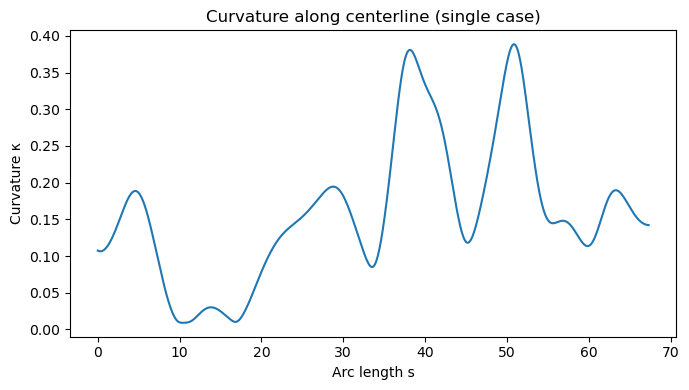

In [35]:
import pandas as pd
import matplotlib.pyplot as plt

# ===== 任选一个 _vals.txt =====
path = r"D:\github\Phd_summary\1_Data\2_Nagahama\1_Centerline\5_centerline_60_curvature_vals\00000010.nii_L_ICA_labeled.txt"

df = pd.read_csv(
    path,
    sep=r"\s+",
    comment="#",
    names=["t", "s", "x", "y", "z", "curvature", "torsion"]
)

plt.figure(figsize=(7, 4))
plt.plot(df["s"], df["curvature"], linewidth=1.5)
plt.xlabel("Arc length s")
plt.ylabel("Curvature κ")
plt.title("Curvature along centerline (single case)")
plt.tight_layout()
plt.show()


In [36]:
import numpy as np
import pyvista as pv
import os

# ========= 路径 =========
input_dir = r"D:\github\Phd_summary\1_Data\2_Nagahama\1_Centerline\5_centerline_60_curvature_vals"
output_dir = r"D:\github\Phd_summary\1_Data\2_Nagahama\1_Centerline\6_centerline_60_vtk"

TARGET_DS = 0.3  # 目标点间距

os.makedirs(output_dir, exist_ok=True)

# ========= 读取 _vals.txt =========
def load_vals(txt_path):
    with open(txt_path, "r", encoding="utf-8", errors="ignore") as f:
        lines = [ln.strip() for ln in f if ln.strip()]

    header = lines[0].lstrip("#").split()
    idx = {name: i for i, name in enumerate(header)}

    s, x, y, z, kappa = [], [], [], [], []

    for ln in lines[1:]:
        parts = ln.split()
        s.append(float(parts[idx["s"]]))
        x.append(float(parts[idx["x"]]))
        y.append(float(parts[idx["y"]]))
        z.append(float(parts[idx["z"]]))
        kappa.append(float(parts[idx["curvature"]]))

    return (
        np.asarray(s),
        np.column_stack([x, y, z]),
        np.asarray(kappa),
    )

# ========= 批量处理 =========
total = 0
success = 0
failed = 0

for fname in os.listdir(input_dir):
    if not fname.endswith(".txt"):
        continue

    total += 1
    in_txt = os.path.join(input_dir, fname)
    out_vtk = os.path.join(
        output_dir,
        os.path.splitext(fname)[0] + "_resampled0.3.vtk"
    )

    try:
        s, pts, curvature = load_vals(in_txt)

        if len(s) < 2:
            print(f"[SKIP] 点数过少: {fname}")
            failed += 1
            continue

        # ===== 沿弧长重采样 =====
        s_new = np.arange(s[0], s[-1] + 1e-8, TARGET_DS)

        x_new = np.interp(s_new, s, pts[:, 0])
        y_new = np.interp(s_new, s, pts[:, 1])
        z_new = np.interp(s_new, s, pts[:, 2])
        k_new = np.interp(s_new, s, curvature)

        pts_new = np.column_stack([x_new, y_new, z_new])

        # ===== 翻转顺序 =====
        pts_new = pts_new[::-1].copy()
        k_new = k_new[::-1].copy()

        # ===== 构建 VTK polyline =====
        n = pts_new.shape[0]
        lines = np.concatenate(([n], np.arange(n))).astype(np.int64)

        poly = pv.PolyData(pts_new)
        poly.lines = lines
        poly.point_data["Curvature"] = k_new

        # ===== 保存 =====
        poly.save(out_vtk, binary=False)

        success += 1

    except Exception as e:
        print(f"[ERROR] {fname}: {e}")
        failed += 1

# ========= 汇总 =========
print("===== Batch finished =====")
print(f"Total files : {total}")
print(f"Success     : {success}")
print(f"Failed      : {failed}")
print(f"Output dir  : {output_dir}")


===== Batch finished =====
Total files : 7559
Success     : 7559
Failed      : 0
Output dir  : D:\github\Phd_summary\1_Data\2_Nagahama\1_Centerline\6_centerline_60_vtk


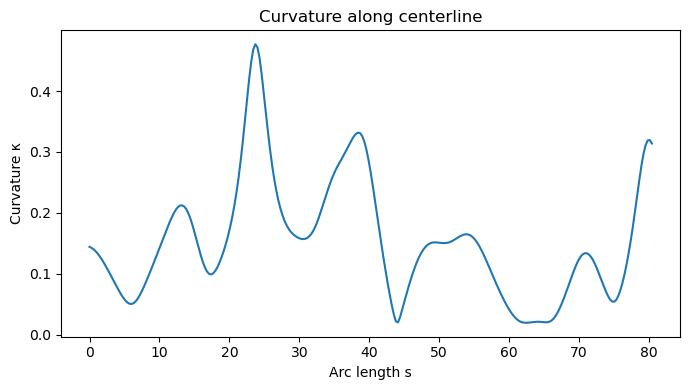

In [39]:
import pyvista as pv
import numpy as np
import matplotlib.pyplot as plt

# ===== VTK 路径 =====
vtk_path = r"D:\github\Phd_summary\1_Data\2_Nagahama\1_Centerline\6_centerline_60_vtk\00000018.nii_R_ICA_labeled_resampled0.3.vtk"

# ===== 读取 VTK =====
mesh = pv.read(vtk_path)

# ===== 提取点和曲率 =====
pts = mesh.points                 # (N, 3)
curv = mesh.point_data["Curvature"]

# ===== 计算弧长 s =====
ds = np.linalg.norm(np.diff(pts, axis=0), axis=1)
s = np.zeros(len(pts))
s[1:] = np.cumsum(ds)

# ===== 画图 =====
plt.figure(figsize=(7, 4))
plt.plot(s, curv, linewidth=1.5)
plt.xlabel("Arc length s")
plt.ylabel("Curvature κ")
plt.title("Curvature along centerline")
plt.tight_layout()
plt.show()
